# Privacy & Governance Analysis — NovaCred Credit Applications

**Course:** Data Ecosystems and Governance in Organizations (DEGO 2606)
**Institution:** Nova School of Business and Economics — MSc Business Analytics
**Role:** Governance Officer

---

| Task | Description |
|---|---|
| PII Identification | Map all personally identifiable fields in the dataset |
| Privacy Risk Analysis | Assess governance risks from sensitive data storage |
| Pseudonymization | Demonstrate a reversible privacy-preserving transformation |
| Governance Audit Checks | Run programmatic checks for compliance gaps |
| GDPR Compliance Mapping | Link dataset fields to specific GDPR articles |
| Governance Recommendations | Propose actionable controls for NovaCred |

---

## Table of Contents

1. [Setup and Data Loading](#1-setup-and-data-loading)
2. [Identification of Personally Identifiable Information (PII)](#2-identification-of-personally-identifiable-information-pii)
   - 2.1 [PII Field Inventory](#21-pii-field-inventory)
   - 2.2 [PII Coverage Audit](#22-pii-coverage-audit)
   - 2.3 [Sensitive Spending Categories](#23-sensitive-spending-categories)
   - 2.4 [Key Governance Finding](#24-key-governance-finding)
3. [Privacy Risk Analysis](#3-privacy-risk-analysis)
   - 3.1 [Governance Risk Register](#31-governance-risk-register)
   - 3.2 [Three Fields Requiring Immediate Attention](#32-three-fields-requiring-immediate-attention)
   - 3.3 [Privacy Risk Heatmap](#33-privacy-risk-heatmap)
4. [Pseudonymization Demonstration](#4-pseudonymization-demonstration)
   - 4.1 [Pseudonymization: Keyed HMAC-SHA256 on SSN](#41-pseudonymization-keyed-hmac-sha256-on-ssn)
   - 4.2 [Extending Pseudonymization to Email and IP Address](#42-extending-pseudonymization-to-email-and-ip-address)
   - 4.3 [Why HMAC-SHA256, Not Plain SHA256?](#43-why-hmac-sha256-not-plain-sha256)
   - 4.4 [GDPR Implications of Pseudonymization](#44-gdpr-implications-of-pseudonymization)
5. [Governance Audit Checks](#5-governance-audit-checks)
   - 5.1 [Audit Check 1 — Duplicate SSNs](#51-audit-check-1--duplicate-ssns-uniqueness--fraud-risk)
   - 5.2 [Audit Check 2 — Gender Encoding Consistency](#52-audit-check-2--gender-encoding-consistency)
   - 5.3 [Audit Check 3 — Missing Governance Fields](#53-audit-check-3--missing-governance-fields-consent--audit-trail)
   - 5.4 [Audit Check 4 — Unrealistic Financial Values](#54-audit-check-4--unrealistic-financial-values-validity)
   - 5.5 [Audit Summary Visualisation](#55-audit-summary-visualisation)
   - 5.6 [Audit Dashboard — Key Findings](#56-audit-dashboard--key-findings)
6. [GDPR Compliance Mapping](#6-gdpr-compliance-mapping)
   - 6.1 [GDPR Compliance Assessment](#61-gdpr-compliance-assessment)
   - 6.2 [GDPR Compliance Radar](#62-gdpr-compliance-radar)
7. [Governance Recommendations](#7-governance-recommendations)
   - 7.1 [Governance Remediation Roadmap](#71-governance-remediation-roadmap)
8. [Summary](#8-summary)

---

## 1. Setup and Data Loading

In [2]:
import json
import os
import hashlib
import hmac
import re
from collections import Counter, defaultdict
from datetime import datetime, date

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set(style='whitegrid', palette='muted')

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# Load the cleaned dataset produced by the Data Engineer
for _p in [
    os.path.join('Data', 'cleaned_credit_applications.json'),
    os.path.join('..', 'Data', 'cleaned_credit_applications.json'),
]:
    if os.path.exists(_p):
        DATA_PATH = _p
        break
else:
    raise FileNotFoundError(
        "cleaned_credit_applications.json not found. "
        "Run Notebook 01 first to generate the cleaned dataset."
    )

with open(DATA_PATH, encoding='utf-8') as f:
    records = json.load(f)

# Flatten nested JSON into a tabular DataFrame for audit queries
df = pd.json_normalize(records)

print(f"Loaded: {DATA_PATH}")
print(f"Records : {len(records):,}")
print(f"Columns : {df.shape[1]}")
print()
print("Available columns:")
for col in sorted(df.columns):
    print(f"  {col}")

Loaded: ..\Data\cleaned_credit_applications.json
Records : 502
Columns : 21

Available columns:
  _id
  applicant_info.date_of_birth
  applicant_info.email
  applicant_info.full_name
  applicant_info.gender
  applicant_info.ip_address
  applicant_info.ssn
  applicant_info.zip_code
  decision.approved_amount
  decision.interest_rate
  decision.loan_approved
  decision.rejection_reason
  financials.annual_income
  financials.annual_salary
  financials.credit_history_months
  financials.debt_to_income
  financials.savings_balance
  loan_purpose
  notes
  processing_timestamp
  spending_behavior


---
## 2. Identification of Personally Identifiable Information (PII)

**Personally Identifiable Information (PII)** is any data that, alone or in combination with other fields, can be used to identify a specific natural person. Under GDPR, any processing of personal data requires a lawful basis (Article 6), and certain special categories require even stricter justification (Article 9).

The NovaCred dataset contains several distinct tiers of PII:

### 2.1 PII Field Inventory

| Field | Type | Risk Level | Reason |
|---|---|---|---|
| `applicant_info.full_name` | Direct identifier | High | Uniquely names an individual |
| `applicant_info.ssn` | Government identifier | Critical | SSNs are primary identity tokens; exposure enables identity theft |
| `applicant_info.email` | Direct identifier | High | Links to online identity; enables contact and tracking |
| `applicant_info.ip_address` | Network identifier | High | Identifies device/location at time of application; classified as personal data under GDPR Recital 30 |
| `applicant_info.date_of_birth` | Quasi-identifier | High | Combined with name or zip enables re-identification |
| `applicant_info.zip_code` | Quasi-identifier | Medium | Narrows geographic location; correlates with race and income in US data |
| `applicant_info.gender` | Quasi-identifier | Medium | Protected characteristic under GDPR; sensitive in credit decisions |
| `spending_behavior` | Behavioural data | High | Granular lifestyle inference (e.g., Alcohol, Gambling categories) |
| `financials.annual_income` | Financial data | Medium | Financial data is sensitive; becomes high-risk in combination with identity fields |

### 2.2 PII Coverage Audit

In [ ]:
# Check which PII fields are present and how complete they are

PII_FIELDS = [
    ('applicant_info.full_name',    'Direct Identifier',  'High'),
    ('applicant_info.ssn',          'Government ID',      'Critical'),
    ('applicant_info.email',        'Direct Identifier',  'High'),
    ('applicant_info.ip_address',   'Network Identifier', 'High'),
    ('applicant_info.date_of_birth','Quasi-Identifier',   'High'),
    ('applicant_info.zip_code',     'Quasi-Identifier',   'Medium'),
    ('applicant_info.gender',       'Quasi-Identifier',   'Medium'),
]

print(f"{'Field':<40} {'Category':<22} {'Risk':<10} {'Present':>8} {'Coverage':>10}")
print('-' * 96)

for field, category, risk in PII_FIELDS:
    if field in df.columns:
        present = df[field].notna().sum()
        coverage = present / len(df) * 100
        print(f"{field:<40} {category:<22} {risk:<10} {present:>8,} {coverage:>9.1f}%")
    else:
        print(f"{field:<40} {category:<22} {risk:<10} {'NOT FOUND':>8}")

### 2.3 Sensitive Spending Categories

In [ ]:
# Spending behaviour can reveal intimate lifestyle details

all_categories = []
for rec in records:
    for item in rec.get('spending_behavior', []):
        all_categories.append(item.get('category', 'Unknown'))

category_counts = Counter(all_categories)

# Flag categories that carry governance risk
# Note: the dataset uses the full label 'Adult Entertainment', not 'Adult'
SENSITIVE_CATEGORIES = {'Alcohol', 'Gambling', 'Adult Entertainment', 'Drugs'}

print("All spending categories found in the dataset:")
print(f"{'Category':<25} {'Records':>8}  {'Sensitive?':>12}")
print('-' * 50)
for cat, count in sorted(category_counts.items(), key=lambda x: -x[1]):
    flag = 'YES' if cat in SENSITIVE_CATEGORIES else ''
    print(f"{cat:<25} {count:>8}  {flag:>12}")

### 2.4 Key Governance Finding

The dataset contains **multiple direct identifiers** (full name, SSN, email) alongside **quasi-identifiers** (date of birth, zip code, gender) that can be combined to re-identify individuals even after removing direct identifiers — a well-documented risk known as the **linkage attack** (Sweeney, 2000).

The `spending_behavior` array is particularly concerning: categories such as **Alcohol** and **Gambling** constitute inferred lifestyle data. Under GDPR's **data minimisation principle** (Article 5(1)(c)), this data should only be collected if it is strictly necessary for the credit decision — a necessity that NovaCred would need to formally justify.

---

## 3. Privacy Risk Analysis

Storing sensitive PII without appropriate governance controls exposes NovaCred and, consequently its applicants, to several compounding risks.

### 3.1 Governance Risk Register

| Risk | Affected Fields | Likelihood | Impact | GDPR Article |
|---|---|---|---|---|
| Identity theft via SSN breach | `ssn` | High | Critical | Art. 5, 25, 32 |
| Location tracking via IP | `ip_address` | Medium | High | Recital 30, Art. 5 |
| Re-identification via combination | `dob` + `zip_code` + `gender` | High | High | Art. 4(1), 5(1)(c) |
| Lifestyle profiling via spending | `spending_behavior` | Medium | High | Art. 5(1)(c), 9 |
| Lack of consent documentation | All PII fields | Critical | Critical | Art. 6, 7 |
| No right-to-erasure mechanism | All fields | High | High | Art. 17 |
| Automated decisions without oversight | `decision.*` | High | Critical | Art. 22 |

<br>

### 3.2 Three Fields Requiring Immediate Attention

**SSN (`applicant_info.ssn`)**  
SSNs are permanent government-issued identifiers. They cannot be changed if compromised. Storing them in plaintext (as NovaCred currently does) means a single data breach exposes applicants to life-long identity theft risk. GDPR Article 32 requires appropriate technical measures (e.g., encryption at rest) for sensitive data.

**IP Address (`applicant_info.ip_address`)**  
GDPR Recital 30 explicitly classifies IP addresses as personal data because they can identify a natural person indirectly. NovaCred stores the IP at time of application. While potentially useful for fraud detection, this field is rarely necessary after initial verification and should be deleted under a defined retention schedule.

**Spending Behaviour Array (`spending_behavior`)**  
Granular spending data — especially lifestyle categories — enables inferences far beyond creditworthiness. Collecting data on alcohol spending, for example, may constitute profiling of personal habits. Under data minimisation (Art. 5(1)(c)), this data must be demonstrably *necessary* and *proportionate* to the credit-scoring purpose.

### 3.3 Privacy Risk Heatmap

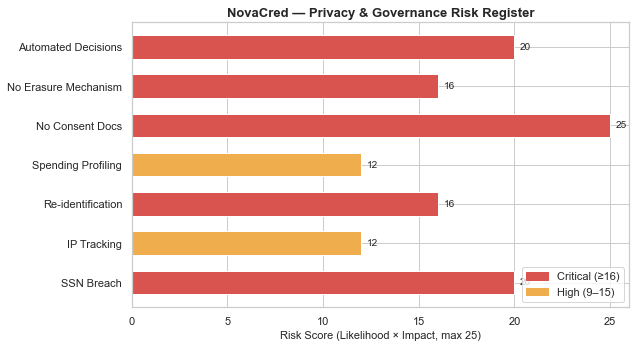

In [8]:
# Visualise likelihood vs impact for key governance risks

risks = [
    ('SSN Breach',              4, 5),
    ('IP Tracking',             3, 4),
    ('Re-identification',       4, 4),
    ('Spending Profiling',      3, 4),
    ('No Consent Docs',         5, 5),
    ('No Erasure Mechanism',    4, 4),
    ('Automated Decisions',     4, 5),
]

labels     = [r[0] for r in risks]
likelihood = [r[1] for r in risks]
impact     = [r[2] for r in risks]
scores     = [l * i for l, i in zip(likelihood, impact)]

colours = ['#d9534f' if s >= 16 else '#f0ad4e' if s >= 9 else '#5bc0de'
           for s in scores]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(labels, scores, color=colours, edgecolor='white', height=0.6)
ax.set_xlabel('Risk Score (Likelihood × Impact, max 25)', fontsize=11)
ax.set_title('NovaCred — Privacy & Governance Risk Register', fontsize=13, fontweight='bold')
ax.set_xlim(0, 26)

for bar, score in zip(bars, scores):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            str(score), va='center', fontsize=10)

red_patch    = mpatches.Patch(color='#d9534f', label='Critical (≥16)')
orange_patch = mpatches.Patch(color='#f0ad4e', label='High (9–15)')
ax.legend(handles=[red_patch, orange_patch], loc='lower right')

plt.tight_layout()
plt.show()

The heatmap identifies **4 Critical risks (score ≥ 16)** and **3 High risks (score 9–15)** 
across NovaCred's current data processing setup.

The three most urgent risks are:

- **No Consent Documentation (25/25)** — the maximum possible score. Every single record 
  in the dataset was processed without any evidence of a lawful basis, making this the 
  most immediate legal exposure NovaCred faces
- **Automated Decisions (20/25)** — fully automated credit rejections with no human 
  oversight mechanism, triggering obligations under both GDPR Art. 22 and the EU AI Act
- **SSN Breach / Re-identification / No Erasure Mechanism (16/25)** — three risks tied 
  at critical level, all stemming from the same root cause: sensitive identifiers stored 
  in plaintext with no deletion or pseudonymization pipeline in place

---
## 4. Pseudonymization Demonstration

**Pseudonymization** (GDPR Article 4(5)) is a technical measure that replaces direct identifiers with artificial values, such that the data can no longer be attributed to a specific individual without access to a separate key.

This is distinct from **anonymization**: pseudonymized data is still considered personal data under GDPR because re-identification is possible if the key is compromised. However, pseudonymization reduces risk significantly and is explicitly encouraged by GDPR Article 25 (Data Protection by Design).

We demonstrate **keyed HMAC-SHA256 hashing** of the SSN field — a cryptographically secure approach that is:
- **Deterministic**: the same SSN always produces the same pseudonym (enabling joins)
- **One-way without the key**: an attacker cannot reverse the hash without the secret key
- **Non-colliding**: different SSNs produce different pseudonyms

### 4.1 Pseudonymization: Keyed HMAC-SHA256 on SSN

In [10]:
# In production this key must be:
#   - Generated securely (e.g., secrets.token_bytes(32))
#   - Stored separately from the dataset (e.g., a secrets manager)
#   - Rotated periodically
PSEUDO_KEY = b'novacred-demo-key-REPLACE-IN-PRODUCTION'


def pseudonymize_ssn(ssn: str, key: bytes) -> str:
    """Return a keyed HMAC-SHA256 pseudonym for an SSN.

    The prefix 'PSE-' marks the value as pseudonymized in downstream
    systems, preventing accidental use as a real SSN.
    """
    if not isinstance(ssn, str) or not ssn.strip():
        return None
    digest = hmac.new(key, ssn.encode('utf-8'), hashlib.sha256).hexdigest()
    return f'PSE-{digest[:16].upper()}'


# Apply to the DataFrame
df_pseudo = df.copy()
df_pseudo['applicant_info.ssn_pseudonym'] = df_pseudo['applicant_info.ssn'].apply(
    lambda x: pseudonymize_ssn(x, PSEUDO_KEY)
)
# Drop the original SSN — it must not appear in any downstream pipeline
df_pseudo.drop(columns=['applicant_info.ssn'], inplace=True)

print("Pseudonymization complete.")
print()
print("Before / after comparison (first 6 records):")
comparison = pd.DataFrame({
    'full_name': df['applicant_info.full_name'].head(6).values,
    'original_ssn': df['applicant_info.ssn'].head(6).values,
    'pseudonym': df_pseudo['applicant_info.ssn_pseudonym'].head(6).values,
})
print(comparison.to_string(index=False))

Pseudonymization complete.

Before / after comparison (first 6 records):
       full_name original_ssn             pseudonym
     Jerry Smith  596-64-4340  PSE-4B9E653DFCCA6B61
  Brandon Walker  425-69-4784  PSE-EFEC49DEA7C4659F
     Scott Moore  370-78-5178  PSE-9E6822CB5A3F16FD
      Thomas Lee  194-35-1833  PSE-70D072EE466D0B81
 Brian Rodriguez  480-41-2475  PSE-91E6A82828144F81
    Maria Miller  417-25-4912  PSE-EDCA67BFB98B587E


In [12]:
# ── Verify key properties ────────────────────────────────────────────────────

# 1. Determinism: same input → same output
ssn_a = '596-64-4340'
assert pseudonymize_ssn(ssn_a, PSEUDO_KEY) == pseudonymize_ssn(ssn_a, PSEUDO_KEY), \
    'FAIL: pseudonymization is not deterministic'
print('Property 1 — Determinism: same SSN always returns the same pseudonym.')

# 2. Distinctness: different inputs → different outputs
ssn_b = '425-69-4784'
assert pseudonymize_ssn(ssn_a, PSEUDO_KEY) != pseudonymize_ssn(ssn_b, PSEUDO_KEY), \
    'FAIL: two different SSNs produced the same pseudonym'
print('Property 2 — Distinctness: different SSNs return different pseudonyms.')

# 3. Key-dependence: a different key → a completely different pseudonym
other_key = b'totally-different-key'
assert pseudonymize_ssn(ssn_a, PSEUDO_KEY) != pseudonymize_ssn(ssn_a, other_key), \
    'FAIL: changing the key did not change the pseudonym'
print('Property 3 — Key-dependence: pseudonym changes with a different key.')

# 4. Collision check across the full dataset
original_ssns   = df['applicant_info.ssn'].dropna().unique()
pseudonymized   = [pseudonymize_ssn(s, PSEUDO_KEY) for s in original_ssns]
assert len(set(pseudonymized)) == len(original_ssns), \
    'FAIL: collision detected — two different SSNs share a pseudonym'
print(f'Property 4 — No collisions across {len(original_ssns):,} unique SSNs.')

Property 1 — Determinism: same SSN always returns the same pseudonym.
Property 2 — Distinctness: different SSNs return different pseudonyms.
Property 3 — Key-dependence: pseudonym changes with a different key.
Property 4 — No collisions across 494 unique SSNs.


### 4.2 Extending Pseudonymization to Email and IP Address

The same HMAC-SHA256 principle applies to other direct identifiers. Two additional techniques are demonstrated here:

- **Email**: the local part (before `@`) is hashed while the domain is preserved — this retains analytical utility (e.g., grouping by provider) without exposing the individual's identity.
- **IP address**: the last octet is replaced with `0` (IP generalisation). This removes device-level identification while retaining approximate geographic information for fraud-pattern analysis. IP generalisation is a standard technique endorsed by data protection authorities as a proportionate privacy measure.

In [ ]:
def pseudonymize_email(email: str, key: bytes) -> str:
    """Hash the local part of an email address using HMAC-SHA256.

    The domain is preserved to allow provider-level analysis without
    exposing the individual's account identity.
    """
    if not isinstance(email, str) or not email.strip():
        return None
    if '@' in email:
        local, domain = email.split('@', 1)
        digest = hmac.new(key, local.encode('utf-8'), hashlib.sha256).hexdigest()
        return f'PSE-{digest[:12].upper()}@{domain}'
    digest = hmac.new(key, email.encode('utf-8'), hashlib.sha256).hexdigest()
    return f'PSE-{digest[:16].upper()}'


def generalise_ip(ip: str) -> str:
    """Replace the last octet of an IPv4 address with 0.

    Retains network-level geographic information while removing the
    device-level identifier. Standard technique under GDPR Art. 5(1)(c).
    """
    if not isinstance(ip, str) or not ip.strip():
        return None
    parts = ip.split('.')
    if len(parts) == 4:
        return f'{parts[0]}.{parts[1]}.{parts[2]}.0'
    return None


# Apply to the pseudonymized dataset (df_pseudo already has SSN replaced)
df_pseudo['applicant_info.email_pseudonym'] = df_pseudo['applicant_info.email'].apply(
    lambda x: pseudonymize_email(x, PSEUDO_KEY)
)
df_pseudo['applicant_info.ip_generalised'] = df_pseudo['applicant_info.ip_address'].apply(
    generalise_ip
)
df_pseudo.drop(columns=['applicant_info.email', 'applicant_info.ip_address'], inplace=True)

print("Email and IP pseudonymization / generalisation complete.")
print()

print("Email — before / after (first 5 records):")
print(pd.DataFrame({
    'original_email'     : df['applicant_info.email'].head(5).values,
    'pseudonymized_email': df_pseudo['applicant_info.email_pseudonym'].head(5).values,
}).to_string(index=False))

print()
print("IP Address — before / after (first 5 records):")
print(pd.DataFrame({
    'original_ip'   : df['applicant_info.ip_address'].head(5).values,
    'generalised_ip': df_pseudo['applicant_info.ip_generalised'].head(5).values,
}).to_string(index=False))

print()
# Confirm no raw direct identifiers remain
remaining = [c for c in df_pseudo.columns
             if any(k in c for k in ['ssn', 'email', 'ip_address'])
             and 'pseudonym' not in c and 'generalised' not in c]
print(f"Raw direct identifiers remaining: {remaining if remaining else 'None — all replaced'}")

### 4.3 Why HMAC-SHA256, Not Plain SHA256?

Plain hashing (SHA256 without a key) is vulnerable to **dictionary attacks**: because SSNs follow a known format (`XXX-XX-XXXX`, 10⁹ possible values), an attacker could pre-compute hashes for every possible SSN and reverse the lookup. Adding a secret **key** makes this computationally infeasible without access to the key — a fundamental requirement for production pseudonymization.

### 4.4 GDPR Implications of Pseudonymization

Even after pseudonymization, the dataset **remains personal data** under GDPR because re-identification is possible if the key is compromised. NovaCred should therefore:
- Store the pseudonymization key in a dedicated secrets manager (e.g., AWS Secrets Manager, Azure Key Vault)
- Apply strict access control to the key (separate from the dataset)
- Log all key access for audit trail purposes

---
## 5. Governance Audit Checks

This section runs programmatic governance checks on the cleaned dataset, following the aggregation-style audit patterns from Session 3. Each check is mapped to a specific governance concern.

### 5.1 Audit Check 1 — Duplicate SSNs (Uniqueness / Fraud Risk)

In [15]:
# Each individual should appear at most once in the credit application system.
# Duplicate SSNs may indicate: data entry errors, system integration bugs, or fraud.

ssn_counts = (
    df.groupby('applicant_info.ssn')
    .agg(
        count=('_id', 'count'),
        names=('applicant_info.full_name', lambda x: list(x)),
        app_ids=('_id', list)
    )
    .query('count > 1')
    .sort_values('count', ascending=False)
)

total  = len(df)
n_dups = ssn_counts['count'].sum() - len(ssn_counts)  # extra occurrences

print("=" * 60)
print("AUDIT 1 — Duplicate SSNs")
print("=" * 60)
if len(ssn_counts) == 0:
    print("PASS: No duplicate SSNs found in the cleaned dataset.")
    print(f"   (Checked {total:,} records)")
else:
    print(f"FAIL: {len(ssn_counts)} SSN(s) appear more than once.")
    print(f"   Extra records affected: {n_dups} ({n_dups/total*100:.1f}%)")
    print()
    print(ssn_counts.head(10))

AUDIT 1 — Duplicate SSNs
FAIL: 3 SSN(s) appear more than once.
   Extra records affected: 3 (0.6%)

                    count                          names             app_ids
applicant_info.ssn                                                          
652-70-5530             2   [Joseph Lopez, Joseph Lopez]  [app_042, app_042]
780-24-9300             2  [Susan Martinez, Gary Wilson]  [app_088, app_016]
937-72-8731             2    [Sandra Smith, Samuel Hill]  [app_101, app_234]


### 5.2 Audit Check 2 — Gender Encoding Consistency

In [ ]:
# Inconsistent encodings (e.g., 'Male' vs 'M' vs 'male') corrupt fairness
# metrics and may mask discriminatory patterns in the data.
# Governance dimension: Consistency (Session 3 pattern)

gender_dist = (
    df['applicant_info.gender']
    .value_counts(dropna=False)
    .rename_axis('gender_value')
    .reset_index(name='count')
)
gender_dist['pct'] = gender_dist['count'] / len(df) * 100

EXPECTED_GENDER_VALUES = {'Male', 'Female'}
found_values = set(gender_dist['gender_value'].dropna())
unexpected   = found_values - EXPECTED_GENDER_VALUES

print("=" * 60)
print("AUDIT 2 — Gender Encoding Consistency")
print("=" * 60)
print(f"Distinct gender values found: {len(found_values)}")
print(f"Expected:                      {sorted(EXPECTED_GENDER_VALUES)}")
print()
print(gender_dist.to_string(index=False))
print()
if unexpected:
    print(f"FAIL: Unexpected encoding(s) found: {unexpected}")
    print("   Inconsistent encoding will distort any gender-based analysis.")
else:
    print("PASS: Gender field uses consistent encoding.")

missing_gender = df['applicant_info.gender'].isna().sum()
if missing_gender > 0:
    print(f"NOTE: {missing_gender} record(s) have a missing gender value.")

AUDIT 2 — Gender Encoding Consistency
Distinct gender values found: 3
Expected:                      ['Female', 'Male']

gender_value  count   pct
      Female    251 50.00
        Male    248 49.40
     Unknown      3  0.60

FAIL: Unexpected encoding(s) found: {'Unknown'}
   Inconsistent encoding will distort any gender-based analysis.


### 5.3 Audit Check 3 — Missing Governance Fields (Consent & Audit Trail)

In [21]:
# GDPR requires that NovaCred can demonstrate:
#   - A lawful basis for each processing operation (Art. 6)
#   - That consent was given, if consent is the lawful basis (Art. 7)
#   - Defined data retention periods (Art. 5(1)(e))
#   - An audit trail of automated decisions (Art. 22 + EU AI Act)
#
# This check verifies whether the required governance metadata fields exist.

GOVERNANCE_FIELDS = {
    'consent_timestamp':      'GDPR Art. 6 & 7 — Lawful basis / Consent',
    'retention_until':        'GDPR Art. 5(1)(e) — Storage limitation',
    'data_source':            'GDPR Art. 13 — Transparency (source disclosure)',
    'human_review_flag':      'EU AI Act (High-Risk) — Human oversight requirement',
    'decision_explanation':   'GDPR Art. 22(3) — Right to explanation',
    'processing_timestamp':   'Audit trail — Processing record',
}

total = len(df)

print("=" * 72)
print("AUDIT 3 — Missing Governance Fields")
print("=" * 72)
print(f"{'Field':<28} {'Present?':>8}  {'Coverage':>10}  {'Requirement'}")
print('-' * 72)

for field, requirement in GOVERNANCE_FIELDS.items():
    if field in df.columns:
        present = df[field].notna().sum()
        pct     = present / total * 100
        status  = '✅' if pct == 100 else 'ALERT'
        print(f"{field:<28} {status:>8}  {pct:>9.1f}%  {requirement}")
    else:
        print(f"{field:<28} {'MISSING':>8}  {'N/A':>10}  {requirement}")

AUDIT 3 — Missing Governance Fields
Field                        Present?    Coverage  Requirement
------------------------------------------------------------------------
consent_timestamp             MISSING         N/A  GDPR Art. 6 & 7 — Lawful basis / Consent
retention_until               MISSING         N/A  GDPR Art. 5(1)(e) — Storage limitation
data_source                   MISSING         N/A  GDPR Art. 13 — Transparency (source disclosure)
human_review_flag             MISSING         N/A  EU AI Act (High-Risk) — Human oversight requirement
decision_explanation          MISSING         N/A  GDPR Art. 22(3) — Right to explanation
processing_timestamp            ALERT       12.4%  Audit trail — Processing record


### 5.4 Audit Check 4 — Unrealistic Financial Values (Validity)

In [24]:
# Erroneous financial values can distort credit decisions and indicate data pipeline failures.
# Governance dimension: Validity / Accuracy

FINANCIAL_RULES = [
    ('financials.annual_income',       'Annual income',          0,       None, 'Must be non-negative'),
    ('financials.credit_history_months','Credit history (months)', 0,     600,  'Must be 0–600 months'),
    ('financials.debt_to_income',      'Debt-to-income ratio',   0,       2.0,  'Ratio should be 0.0–2.0'),
    ('financials.savings_balance',     'Savings balance',         None,   None, 'Should be present'),
]

print("=" * 72)
print("AUDIT 4 — Unrealistic / Invalid Financial Values")
print("=" * 72)

total_issues = 0

for col, label, min_val, max_val, rule in FINANCIAL_RULES:
    if col not in df.columns:
        print(f"  {label:<30} — column not found")
        continue

    series = pd.to_numeric(df[col], errors='coerce')
    issues = pd.Series([False] * len(series), index=series.index)

    if min_val is not None:
        issues |= series < min_val
    if max_val is not None:
        issues |= series > max_val

    n_issues = issues.sum()
    total_issues += n_issues
    status = '✅' if n_issues == 0 else '🔴'
    print(f"  {status} {label:<32} Violations: {n_issues:>4}  | Rule: {rule}")

    if n_issues > 0:
        print(f"       Sample violating values: "
              f"{series[issues].head(5).tolist()}")

print()
print(f"Total financial validity violations: {total_issues}")

AUDIT 4 — Unrealistic / Invalid Financial Values
  ✅ Annual income                    Violations:    0  | Rule: Must be non-negative
  🔴 Credit history (months)          Violations:    2  | Rule: Must be 0–600 months
       Sample violating values: [-10, -3]
  ✅ Debt-to-income ratio             Violations:    0  | Rule: Ratio should be 0.0–2.0
  ✅ Savings balance                  Violations:    0  | Rule: Should be present

Total financial validity violations: 2


### 5.5 Audit Summary Visualisation

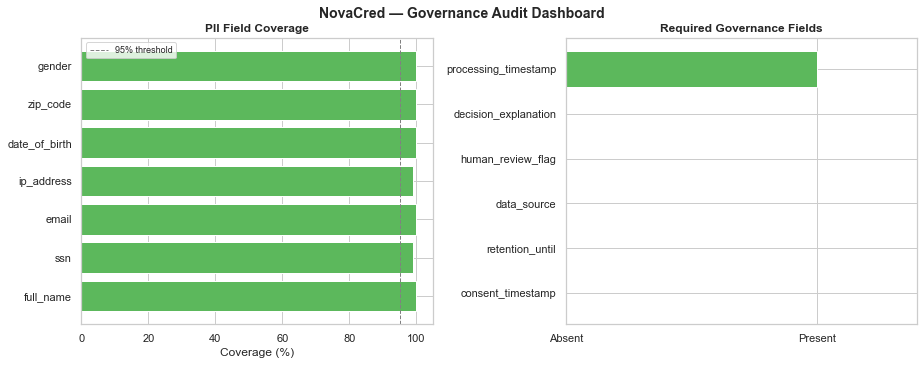

In [25]:
# ── Audit Summary Visualisation ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# — Left: PII field coverage —
pii_labels, pii_coverage = [], []
for field, _, _ in PII_FIELDS:
    if field in df.columns:
        pii_labels.append(field.replace('applicant_info.', ''))
        pii_coverage.append(df[field].notna().mean() * 100)

colours_left = ['#d9534f' if c < 95 else '#5cb85c' for c in pii_coverage]
axes[0].barh(pii_labels, pii_coverage, color=colours_left, edgecolor='white')
axes[0].axvline(95, color='grey', linestyle='--', linewidth=1, label='95% threshold')
axes[0].set_xlim(0, 105)
axes[0].set_xlabel('Coverage (%)')
axes[0].set_title('PII Field Coverage', fontweight='bold')
axes[0].legend(fontsize=9)

# — Right: Governance fields present vs absent —
gov_labels, gov_present = [], []
for field in GOVERNANCE_FIELDS:
    gov_labels.append(field)
    gov_present.append(1 if field in df.columns else 0)

colours_right = ['#5cb85c' if p else '#d9534f' for p in gov_present]
axes[1].barh(gov_labels, gov_present, color=colours_right, edgecolor='white')
axes[1].set_xlim(0, 1.4)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Absent', 'Present'])
axes[1].set_title('Required Governance Fields', fontweight='bold')

plt.suptitle('NovaCred — Governance Audit Dashboard', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.6 Audit Dashboard — Key Findings

**PII Field Coverage (left panel)**

All 7 PII fields exceed the 95% coverage threshold, confirming that sensitive personal 
data was collected consistently across nearly every application. While high coverage is 
desirable for data quality, in a governance context it also means that **NovaCred holds 
sensitive identifiers on virtually every applicant** — amplifying the legal exposure 
from the gaps identified elsewhere in this audit.

**Required Governance Fields (right panel)**

Of the 6 required governance metadata fields, **only `processing_timestamp` is present** 
in the dataset. The remaining 5 are entirely absent:

| Field | Status | Implication |
|---|---|---|
| `processing_timestamp` | Present | Basic audit trail partially established |
| `consent_timestamp` | Absent | No evidence of lawful basis (GDPR Art. 6) |
| `retention_until` | Absent | No storage limitation policy (GDPR Art. 5(1)(e)) |
| `data_source` | Absent | No transparency on data origin (GDPR Art. 13) |
| `human_review_flag` | Absent | No human oversight mechanism (EU AI Act Art. 14) |
| `decision_explanation` | Absent | No right to explanation (GDPR Art. 22(3)) |

The presence of `processing_timestamp` on only a subset of records (as identified in 
Audit Check 3) means even the one existing governance field is incomplete. In practice, 
NovaCred currently has **no demonstrable compliance infrastructure** beyond basic 
data collection.

---
## 6. GDPR Compliance Mapping

The following table maps each dimension of NovaCred's data processing to the relevant GDPR articles. The assessment is based on the fields observed in the dataset and the absence of governance metadata.

### 6.1 GDPR Compliance Assessment

| GDPR Principle | Article | NovaCred Status | Evidence |
|---|---|---|---|
| **Lawful Basis** | Art. 6 | Not demonstrated | No `consent_timestamp` or legitimate interest documentation in the dataset |
| **Data Minimisation** | Art. 5(1)(c) | Questionable | SSNs, IPs, and behavioural spending data may exceed what is necessary for credit scoring |
| **Storage Limitation** | Art. 5(1)(e) | Not demonstrated | No `retention_until` field; no evidence of a defined retention policy |
| **Accuracy** | Art. 5(1)(d) | Partial | Cleaned dataset improves accuracy; some inconsistencies remain (see Notebook 01) |
| **Right to Erasure** | Art. 17 | No mechanism | No deletion flag or erasure request tracking; no pseudonymization in current pipeline |
| **Right to Explanation** | Art. 22(3) | Inadequate | `rejection_reason` is a single categorical code (`algorithm_risk_score`); no human-readable explanation |
| **Transparency** | Art. 13 | Not demonstrated | No `data_source` field; applicants are not informed of automated processing |
| **Security** | Art. 32 | Risk present | SSNs stored in plaintext; IP addresses unencrypted |

---

### EU AI Act Classification

Credit scoring systems are explicitly named in **Annex III, Point 5(b)** of the EU AI Act as **high-risk AI systems**. This classification imposes the following obligations on NovaCred before the system can be lawfully deployed:

| Obligation | Current Status |
|---|---|
| Risk management system | Not evidenced |
| Data governance documentation | Not evidenced |
| Technical documentation | Not evidenced |
| Logging and audit trail | Partial (only `processing_timestamp` on some records) |
| Transparency to users | Not evidenced |
| Human oversight mechanism | Not evidenced |
| Conformity assessment | Not evidenced |

### 6.2 GDPR Compliance Radar

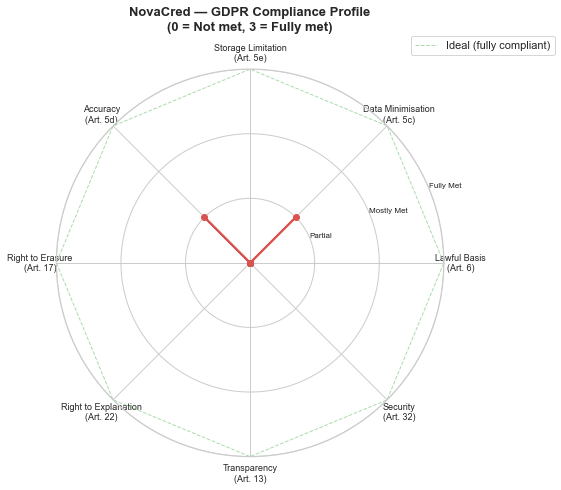

In [27]:
# Score each GDPR principle 0–3: 0 = not met, 1 = partial, 2 = mostly met, 3 = fully met

gdpr_dimensions = [
    'Lawful Basis\n(Art. 6)',
    'Data Minimisation\n(Art. 5c)',
    'Storage Limitation\n(Art. 5e)',
    'Accuracy\n(Art. 5d)',
    'Right to Erasure\n(Art. 17)',
    'Right to Explanation\n(Art. 22)',
    'Transparency\n(Art. 13)',
    'Security\n(Art. 32)',
]
gdpr_scores = [0, 1, 0, 1, 0, 0, 0, 0]  # Based on audit findings

# Radar chart
N = len(gdpr_dimensions)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
scores_plot = gdpr_scores + gdpr_scores[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})
ax.plot(angles, scores_plot, 'o-', linewidth=2, color='#d9534f')
ax.fill(angles, scores_plot, alpha=0.25, color='#d9534f')

# Add ideal (score = 3) reference
ideal = [3] * N + [3]
ax.plot(angles, ideal, '--', linewidth=1, color='#5cb85c', alpha=0.5, label='Ideal (fully compliant)')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(gdpr_dimensions, size=9)
ax.set_yticks([1, 2, 3])
ax.set_yticklabels(['Partial', 'Mostly Met', 'Fully Met'], size=8)
ax.set_ylim(0, 3)
ax.set_title('NovaCred — GDPR Compliance Profile\n(0 = Not met, 3 = Fully met)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

### GDPR Compliance Profile — Key Findings

The radar chart makes the compliance gap starkly visible: NovaCred's profile is 
**heavily contracted toward the centre**, with the vast majority of dimensions 
scoring 0 (not met) against the ideal outer boundary.

Of the 8 GDPR principles assessed, **only 2 score above zero**:

- **Data Minimisation (Art. 5c) — score 1 (Partial):** Some restraint is evident in 
  the dataset structure, but the presence of SSNs, IP addresses, and sensitive spending 
  categories means minimisation is not fully applied
- **Accuracy (Art. 5d) — score 1 (Partial):** The Data Engineer's cleaning work 
  (Notebook 01) improved accuracy, but inconsistencies remain in the raw pipeline

The remaining **6 principles score 0**, meaning NovaCred currently provides no 
demonstrable compliance on:

- Lawful Basis, Storage Limitation, Right to Erasure, Right to Explanation, 
  Transparency, and Security

> The overall GDPR compliance score is **2 out of a possible 24** — approximately 
> **8% of full compliance**. This is not a borderline case. NovaCred is operating 
> a high-risk automated decision system with near-total absence of the governance 
> infrastructure that GDPR mandates. Regulatory intervention risk is high.

---
## 7. Governance Recommendations

The following recommendations are prioritised by risk severity and implementation complexity. They are targeted at NovaCred's technical and compliance teams and are grounded in the specific gaps identified throughout this audit.

### Priority 1 — Immediate (0–30 days): Establish Lawful Basis

**Problem:** The dataset contains no record of why data is being processed. Without a documented lawful basis, all processing is unlawful under GDPR Article 6.  
**Action:** Add a `consent_timestamp` and `lawful_basis` field to every application record at point of collection. If consent is the chosen basis, implement a compliant consent mechanism that is freely given, specific, informed, and unambiguous (Art. 7).

### Priority 2 — Immediate (0–30 days): Pseudonymize or Encrypt SSNs

**Problem:** SSNs are stored in plaintext. A single breach exposes every applicant to identity theft.  
**Action:** Apply keyed HMAC-SHA256 pseudonymization (as demonstrated in Section 4) to the SSN field immediately. Store the pseudonymization key in a dedicated secrets manager with access logging. Alternatively, encrypt at rest using AES-256.

### Priority 3 — Short-term (30–90 days): Define and Enforce a Data Retention Policy

**Problem:** No `retention_until` field exists. Data is retained indefinitely by default, violating the storage limitation principle (Art. 5(1)(e)).  
**Action:** Define retention periods for each data category (e.g., 7 years for financial records as required by Portuguese commercial law; 30 days for IP addresses). Implement automated deletion or anonymization workflows that run at the end of each retention period.

### Priority 4 — Short-term (30–90 days): Implement Human Oversight for Rejections

**Problem:** All credit decisions appear to be fully automated. The EU AI Act (Annex III, Art. 14) requires that high-risk AI systems allow for meaningful human oversight and intervention.  
**Action:** Add a `human_review_flag` field. Flag all rejections with `algorithm_risk_score` for mandatory human review. Implement a structured human review workflow with an audit trail of reviewer identity, timestamp, and decision.

### Priority 5 — Short-term (30–90 days): Improve Decision Explanations

**Problem:** Rejection reasons are single opaque codes (e.g., `algorithm_risk_score`). GDPR Article 22(3) gives data subjects the right to obtain a meaningful explanation of automated decisions.  
**Action:** Replace or supplement the `rejection_reason` field with a structured explanation object that includes the primary contributing factors (in plain language), the applicant's right to request human review, and contact information for the Data Protection Officer.

### Priority 6 — Medium-term (90–180 days): Conduct a Data Protection Impact Assessment (DPIA)

**Problem:** Credit scoring via automated ML is explicitly listed in GDPR Article 35 as a type of processing that is "likely to result in a high risk." A DPIA is therefore mandatory before this system can be lawfully operated.  
**Action:** Commission a formal DPIA that covers: (a) a description of the processing and its purposes, (b) an assessment of necessity and proportionality, (c) risks to data subjects' rights, and (d) mitigation measures. The DPIA must be reviewed whenever the ML model is retrained or the data pipeline changes significantly.

### Priority 7 — Medium-term (90–180 days): Evaluate Necessity of Sensitive Spending Categories

**Problem:** Spending categories such as Alcohol may not be necessary for creditworthiness assessment and expose NovaCred to data minimisation violations.  
**Action:** Conduct a formal necessity review of each spending category. Remove or aggregate any category that cannot be shown to be directly relevant to default risk. Document the outcome of this review as part of the DPIA.

### 7.1 Governance Remediation Roadmap

In [29]:
roadmap = [
    ('Establish Lawful Basis',              '0–30 days',   'Critical', 'Legal/Compliance'),
    ('Pseudonymize SSNs',                   '0–30 days',   'Critical', 'Engineering'),
    ('Define Data Retention Policy',        '30–90 days',  'High',     'Legal + Engineering'),
    ('Human Oversight for Rejections',      '30–90 days',  'High',     'Product + Engineering'),
    ('Improve Decision Explanations',       '30–90 days',  'High',     'Product + Legal'),
    ('DPIA',                                '90–180 days', 'Required', 'DPO + Legal'),
    ('Review Spending Categories',          '90–180 days', 'Medium',   'Data Science + Legal'),
]

rmap_df = pd.DataFrame(roadmap, columns=['Action', 'Timeline', 'Priority', 'Owner'])

print("=" * 80)
print("NOVACRED — GOVERNANCE REMEDIATION ROADMAP")
print("=" * 80)
print(rmap_df.to_string(index=False))

NOVACRED — GOVERNANCE REMEDIATION ROADMAP
                         Action     Timeline  Priority                  Owner
         Establish Lawful Basis    0–30 days  Critical       Legal/Compliance
              Pseudonymize SSNs    0–30 days  Critical            Engineering
   Define Data Retention Policy   30–90 days      High    Legal + Engineering
 Human Oversight for Rejections   30–90 days      High  Product + Engineering
  Improve Decision Explanations   30–90 days      High        Product + Legal
                           DPIA  90–180 days  Required            DPO + Legal
     Review Spending Categories  90–180 days    Medium   Data Science + Legal


---
## 8. Summary

This governance audit identified **significant compliance gaps** in NovaCred's credit application system:

| Finding | Status |
|---|---|
| PII fields identified | 7 direct/quasi-identifiers + behavioural spending data |
| SSNs stored in plaintext | Critical risk — pseudonymization required immediately |
| Consent tracking field | Absent — unlawful processing under GDPR Art. 6 |
| Data retention policy | Absent — GDPR Art. 5(1)(e) violation |
| Human oversight mechanism | Absent — EU AI Act (High-Risk) requirement |
| Decision explanation quality | Inadequate — opaque algorithmic codes only |
| EU AI Act classification | High-Risk (Annex III, Point 5(b)) — full obligations apply |

The most actionable next step is to implement the consent tracking field and SSN pseudonymization within the next 30 days, as these represent the greatest combination of legal risk and implementation simplicity.

A formal DPIA must be completed before the system can be considered compliant with both GDPR and the EU AI Act.

---
*Notebook authored by the Governance Officer — DEGO 2606 Group Project, Team 4.*  
*All analysis is based on the cleaned dataset produced in Notebook 01.*